Install packages

In [80]:
!pip install mne torch numpy scipy matplotlib umap-learn scikit-learn pandas -q

Imports and configuration

In [81]:
import os
import json
import random
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import mne
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf

from scipy.signal import butter, sosfiltfilt

from sklearn.metrics import accuracy_score, balanced_accuracy_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import umap
import matplotlib.pyplot as plt
from IPython.display import display


# ============================================================
# Debug/final mode
# ============================================================

FAST_DEBUG = False

if FAST_DEBUG:
    SEEDS = [42]
    EPOCHS_BASELINE = 60
    EPOCHS_SWEEP = 60
else:
    SEEDS = [42, 7, 123]
    EPOCHS_BASELINE = 60
    EPOCHS_SWEEP = 60


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

RESULTS_DIR = "results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("Device:", DEVICE)
print("Seeds:", SEEDS)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_json_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

Device: cuda
Seeds: [42, 7, 123]


Assignment setup

In [82]:
# ============================================================
# Assignment fixed subset
# ============================================================

TRAIN_SUBJECTS_FULL = [1, 2, 3, 4, 5, 6, 7, 8]
TRAIN_SUBJECTS_SMALL = [1, 2, 3]
TEST_SUBJECTS = [9, 10]

RUNS = [6, 10, 14]

# EEGBCI/MNE interpretation:
# Runs 6, 10, 14 correspond to motor imagery: hands/fists vs feet.
# The assignment text says left/right fist, but the selected runs are the
# hands-vs-feet motor imagery runs.

# ============================================================
# EEG preprocessing
# ============================================================

LOW_FREQ = 4.0
HIGH_FREQ = 38.0

# EEGBCI original sampling rate is 160 Hz.
RESAMPLE_RATE = 160

# EEGNet-style motor imagery window.
# With 160 Hz and inclusive MNE epoching, this gives 321 time samples.
TMIN = 0.5
TMAX = 2.5

EVENT_ID = {
    "T1": 0,
    "T2": 1
}

# ============================================================
# Training setup
# ============================================================

BATCH_SIZE = 32
LR = 1e-3

# Paper-faithful EEGNet max-norm constraints.
USE_MAX_NORM = True

# Predeclared representative settings for plots/write-up.
# These are not selected using the test set.
MAIN_CCSA_BETA = 0.8
MAIN_APMRG_LAMBDA = 0.1

Data loading

In [83]:
@dataclass
class EpochSet:
    X: np.ndarray
    y: np.ndarray
    subjects: np.ndarray
    ch_names: List[str]


def load_subject_raw(subject: int, runs: List[int]):
    raw_fnames = eegbci.load_data(subject, runs)
    raws = [read_raw_edf(f, preload=True, verbose=False) for f in raw_fnames]
    raw = concatenate_raws(raws)

    eegbci.standardize(raw)
    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage, on_missing="ignore")

    return raw


def preprocess_raw(raw):
    raw.pick_types(eeg=True, meg=False, stim=False)
    raw.filter(LOW_FREQ, HIGH_FREQ, fir_design="firwin", verbose=False)
    raw.resample(RESAMPLE_RATE, verbose=False)
    return raw


def raw_to_epochs(raw):
    events, event_dict = mne.events_from_annotations(raw, verbose=False)

    valid_event_id = {}
    for key in EVENT_ID:
        if key in event_dict:
            valid_event_id[key] = event_dict[key]

    epochs = mne.Epochs(
        raw,
        events,
        event_id=valid_event_id,
        tmin=TMIN,
        tmax=TMAX,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()

    inv_event_dict = {v: k for k, v in event_dict.items()}

    y = []
    for event_code in epochs.events[:, -1]:
        label_name = inv_event_dict[event_code]
        y.append(EVENT_ID[label_name])

    y = np.asarray(y, dtype=np.int64)

    return X, y, epochs.ch_names


def per_trial_zscore(X):
    """
    Per-trial, per-channel temporal z-score.

    This removes trivial offset/scale differences across subjects and sessions
    while keeping temporal and spatial EEG structure.
    """
    mean = X.mean(axis=-1, keepdims=True)
    std = X.std(axis=-1, keepdims=True) + 1e-6
    return (X - mean) / std


def load_dataset(subjects: List[int], runs: List[int]) -> EpochSet:
    all_X = []
    all_y = []
    all_subjects = []
    ch_names_ref = None

    for subj in subjects:
        print(f"Loading subject {subj}...")
        raw = load_subject_raw(subj, runs)
        raw = preprocess_raw(raw)

        X, y, ch_names = raw_to_epochs(raw)
        X = per_trial_zscore(X)

        all_X.append(X)
        all_y.append(y)
        all_subjects.append(np.full(len(y), subj))

        if ch_names_ref is None:
            ch_names_ref = ch_names

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    subjects_arr = np.concatenate(all_subjects, axis=0)

    return EpochSet(
        X=X,
        y=y,
        subjects=subjects_arr,
        ch_names=ch_names_ref
    )


print("Loading EEGBCI data...")

full_train_set = load_dataset(TRAIN_SUBJECTS_FULL, RUNS)
small_train_set = load_dataset(TRAIN_SUBJECTS_SMALL, RUNS)
test_set = load_dataset(TEST_SUBJECTS, RUNS)

print("Full train:", full_train_set.X.shape)
print("Small train:", small_train_set.X.shape)
print("Test:", test_set.X.shape)
print("Channels:", len(full_train_set.ch_names))
print("Time samples:", full_train_set.X.shape[-1])

Loading EEGBCI data...
Loading subject 1...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 2...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 3...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 4...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 5...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 6...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 7...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 8...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 1...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Loading subject 2...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...

Dataset and DataLoader

In [84]:
class EEGDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, subjects):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.subjects = torch.tensor(subjects, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # EEGNet input: batch x 1 x channels x time
        return self.X[idx].unsqueeze(0), self.y[idx], self.subjects[idx]


def make_loader(X, y, subjects, batch_size=32, shuffle=True):
    ds = EEGDataset(X, y, subjects)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle
    )

Paper-faithful EEGNet

In [85]:
class EEGNet(nn.Module):
    """
    EEGNet-8,2 — faithful PyTorch-style implementation.

    F1=8, D=2, F2=16.
    Temporal kernel length = 80 for 160 Hz EEG.
    Depthwise spatial conv and final dense layer use max-norm projection
    after optimizer.step().
    """

    def __init__(
        self,
        n_channels: int = 64,
        n_times: int = 321,
        n_classes: int = 2,
        F1: int = 8,
        D: int = 2,
        kern_len: int = 80,
        dropout: float = 0.5,
    ):
        super().__init__()

        F2 = F1 * D
        self.F2 = F2

        self.temporal = nn.Conv2d(
            1,
            F1,
            kernel_size=(1, kern_len),
            padding=(0, kern_len // 2),
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(F1)

        self.depthwise = nn.Conv2d(
            F1,
            F1 * D,
            kernel_size=(n_channels, 1),
            groups=F1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(F2)

        self.elu = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)

        self.sep_depth = nn.Conv2d(
            F2,
            F2,
            kernel_size=(1, 16),
            padding=(0, 8),
            groups=F2,
            bias=False
        )

        self.sep_point = nn.Conv2d(
            F2,
            F2,
            kernel_size=(1, 1),
            bias=False
        )

        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout)

        # Robust flat dimension calculation.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            h = self.features(dummy)
            self.flat_dim = h.shape[1]

        self.fc = nn.Linear(self.flat_dim, n_classes)

    def features(self, x):
        # Accept both (B, C, T) and (B, 1, C, T).
        if x.dim() == 3:
            x = x.unsqueeze(1)

        x = self.temporal(x)
        x = self.bn1(x)

        x = self.depthwise(x)
        x = self.bn2(x)

        x = self.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sep_depth(x)
        x = self.sep_point(x)
        x = self.bn3(x)

        x = self.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x.flatten(1)

    def extract_features(self, x):
        return self.features(x)

    def forward(self, x, return_features=False):
        h = self.features(x)
        logits = self.fc(h)

        if return_features:
            return logits, h

        return logits

In [86]:
def project_eegnet_max_norm(model, depthwise_max_norm=1.0, dense_max_norm=0.25):
    """
    Apply EEGNet max-norm constraints after optimizer.step().

    Depthwise spatial convolution: max_norm = 1.0
    Final dense layer: max_norm = 0.25
    """

    def project_weight(weight, max_norm):
        with torch.no_grad():
            w = weight.data
            w_flat = w.reshape(w.shape[0], -1)
            norms = w_flat.norm(p=2, dim=1, keepdim=True).clamp(min=1e-8)
            desired = torch.clamp(norms, max=max_norm)
            w_flat.mul_(desired / norms)

    if hasattr(model, "depthwise"):
        project_weight(model.depthwise.weight, depthwise_max_norm)

    if hasattr(model, "fc"):
        project_weight(model.fc.weight, dense_max_norm)

Training and evaluation utilities

In [87]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch, _ in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()
        project_eegnet_max_norm(model)

        total_loss += loss.item() * len(y_batch)

        preds = logits.argmax(dim=1).detach().cpu().numpy()
        labels = y_batch.detach().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds)
    }


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch, _ in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        total_loss += loss.item() * len(y_batch)

        preds = logits.argmax(dim=1).cpu().numpy()
        labels = y_batch.cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds)
    }


@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval()

    Z = []
    Y = []
    S = []

    for X_batch, y_batch, s_batch in loader:
        X_batch = X_batch.to(DEVICE)

        _, z = model(X_batch, return_features=True)

        Z.append(z.cpu().numpy())
        Y.append(y_batch.numpy())
        S.append(s_batch.numpy())

    return np.concatenate(Z), np.concatenate(Y), np.concatenate(S)

Representation diagnostics

In [88]:
def representation_diagnostics(Z, y, subjects):
    class_sil = silhouette_score(Z, y) if len(np.unique(y)) > 1 else np.nan
    subject_sil = silhouette_score(Z, subjects) if len(np.unique(subjects)) > 1 else np.nan

    return {
        "class_silhouette": float(class_sil),
        "subject_silhouette": float(subject_sil)
    }


def linear_probe_scores(Z, y, subjects, seed=42):
    """
    Diagnostic probes.

    Class probe:
        Higher is better because task information is linearly recoverable.

    Subject probe:
        Lower is better because less subject identity is encoded.
    """
    idx_train, idx_test = train_test_split(
        np.arange(len(y)),
        test_size=0.3,
        random_state=seed,
        stratify=y
    )

    scaler_c = StandardScaler()
    Ztr = scaler_c.fit_transform(Z[idx_train])
    Zte = scaler_c.transform(Z[idx_test])

    class_probe = LogisticRegression(max_iter=5000)
    class_probe.fit(Ztr, y[idx_train])
    class_pred = class_probe.predict(Zte)

    class_acc = accuracy_score(y[idx_test], class_pred)

    idx_train_s, idx_test_s = train_test_split(
        np.arange(len(subjects)),
        test_size=0.3,
        random_state=seed,
        stratify=subjects
    )

    scaler_s = StandardScaler()
    Ztr_s = scaler_s.fit_transform(Z[idx_train_s])
    Zte_s = scaler_s.transform(Z[idx_test_s])

    subject_probe = LogisticRegression(max_iter=5000)
    subject_probe.fit(Ztr_s, subjects[idx_train_s])
    subject_pred = subject_probe.predict(Zte_s)

    subject_acc = accuracy_score(subjects[idx_test_s], subject_pred)
    subject_chance = 1.0 / len(np.unique(subjects))

    return {
        "class_probe_accuracy": float(class_acc),
        "subject_probe_accuracy": float(subject_acc),
        "subject_chance_level": float(subject_chance)
    }


def plot_umap(Z, color_values, title, filename):
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=SEEDS[0]
    )

    U = reducer.fit_transform(Z)

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(
        U[:, 0],
        U[:, 1],
        c=color_values,
        cmap="tab10",
        s=18,
        alpha=0.85
    )
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.colorbar(sc)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

    return U

Standard fixed-epoch EEGNet run

In [89]:
def run_standard_eegnet(
    train_set: EpochSet,
    test_set: EpochSet,
    seed: int,
    epochs: int,
    experiment_name: str
):
    """
    Fixed-epoch training.

    No validation set is used because the assignment specifies only:
        train subjects 1-8, test subjects 9-10.

    This avoids training on fewer than the assigned training subjects.
    """
    set_seed(seed)

    n_channels = train_set.X.shape[1]
    n_times = train_set.X.shape[2]

    train_loader = make_loader(
        train_set.X,
        train_set.y,
        train_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    test_loader = make_loader(
        test_set.X,
        test_set.y,
        test_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    dev_loader = make_loader(
        train_set.X,
        train_set.y,
        train_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = EEGNet(
        n_channels=n_channels,
        n_times=n_times
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_bal_acc": [],
        "train_loss": []
    }

    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        history["train_bal_acc"].append(float(train_stats["balanced_accuracy"]))
        history["train_loss"].append(float(train_stats["loss"]))

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"{experiment_name} | seed={seed} | epoch={epoch:03d} | "
                f"train_bal={train_stats['balanced_accuracy']:.3f} | "
                f"train_loss={train_stats['loss']:.4f}"
            )

    test_stats = evaluate(model, test_loader, criterion)

    Z, Y, S = extract_embeddings(model, dev_loader)

    diag = representation_diagnostics(Z, Y, S)
    probes = linear_probe_scores(Z, Y, S, seed=seed)

    row = {
        "experiment_name": experiment_name,
        "seed": int(seed),
        "test_accuracy": float(test_stats["accuracy"]),
        "test_balanced_accuracy": float(test_stats["balanced_accuracy"]),
        **diag,
        **probes
    }

    return {
        "row": row,
        "model": model,
        "history": history,
        "Z_train": Z,
        "Y_train": Y,
        "S_train": S
    }

Part 1: EEGNet baseline and reduced-subject failure

In [90]:
part1_rows = []
part1_results = {}

for seed in SEEDS:
    print("\n" + "=" * 90)
    print(f"Part 1 EEGNet full train 1-8 | seed={seed}")
    print("=" * 90)

    res_full = run_standard_eegnet(
        full_train_set,
        test_set,
        seed=seed,
        epochs=EPOCHS_BASELINE,
        experiment_name="Part1_EEGNet_full_train_1_to_8"
    )

    print("\n" + "=" * 90)
    print(f"Part 1 EEGNet reduced train 1-3 | seed={seed}")
    print("=" * 90)

    res_small = run_standard_eegnet(
        small_train_set,
        test_set,
        seed=seed,
        epochs=EPOCHS_BASELINE,
        experiment_name="Part1_EEGNet_reduced_train_1_to_3"
    )

    part1_rows.append(res_full["row"])
    part1_rows.append(res_small["row"])

    part1_results[("full", seed)] = res_full
    part1_results[("small", seed)] = res_small

part1_df = pd.DataFrame(part1_rows)
display(part1_df)

part1_df.to_csv("results/part1_raw.csv", index=False)


Part 1 EEGNet full train 1-8 | seed=42
Part1_EEGNet_full_train_1_to_8 | seed=42 | epoch=001 | train_bal=0.463 | train_loss=0.6992
Part1_EEGNet_full_train_1_to_8 | seed=42 | epoch=010 | train_bal=0.607 | train_loss=0.6698
Part1_EEGNet_full_train_1_to_8 | seed=42 | epoch=020 | train_bal=0.700 | train_loss=0.6152
Part1_EEGNet_full_train_1_to_8 | seed=42 | epoch=030 | train_bal=0.706 | train_loss=0.5869
Part1_EEGNet_full_train_1_to_8 | seed=42 | epoch=040 | train_bal=0.741 | train_loss=0.5475
Part1_EEGNet_full_train_1_to_8 | seed=42 | epoch=050 | train_bal=0.769 | train_loss=0.4947
Part1_EEGNet_full_train_1_to_8 | seed=42 | epoch=060 | train_bal=0.806 | train_loss=0.4320

Part 1 EEGNet reduced train 1-3 | seed=42
Part1_EEGNet_reduced_train_1_to_3 | seed=42 | epoch=001 | train_bal=0.474 | train_loss=0.6959
Part1_EEGNet_reduced_train_1_to_3 | seed=42 | epoch=010 | train_bal=0.614 | train_loss=0.6638
Part1_EEGNet_reduced_train_1_to_3 | seed=42 | epoch=020 | train_bal=0.696 | train_loss=0.631

,experiment_name,seed,test_accuracy,test_balanced_accuracy,class_silhouette,subject_silhouette,class_probe_accuracy,subject_probe_accuracy,subject_chance_level
0,Part1_EEGNet_full_train_1_to_8,42,0.555556,0.557312,0.088467,-0.048322,0.916667,0.583333,0.125000
1,Part1_EEGNet_reduced_train_1_to_3,42,0.533333,0.537055,0.127814,-0.023581,0.829268,0.804878,0.333333
2,Part1_EEGNet_full_train_1_to_8,7,0.600000,0.597826,0.110979,-0.065288,0.861111,0.620370,0.125000
3,Part1_EEGNet_reduced_train_1_to_3,7,0.544444,0.542984,0.047139,0.036751,0.658537,0.804878,0.333333
4,Part1_EEGNet_full_train_1_to_8,123,0.622222,0.619565,0.134386,-0.097445,0.842593,0.592593,0.125000
5,Part1_EEGNet_reduced_train_1_to_3,123,0.588889,0.589427,0.057022,-0.014891,0.926829,0.731707,0.333333


Aggregation helper and Part 1 UMAP

,experiment_name,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_balanced_accuracy_best,test_balanced_accuracy_worst,class_probe_accuracy_mean,class_probe_accuracy_std,class_probe_accuracy_best,class_probe_accuracy_worst,subject_probe_accuracy_mean,...,subject_probe_accuracy_best,subject_probe_accuracy_worst,class_silhouette_mean,class_silhouette_std,class_silhouette_best,class_silhouette_worst,subject_silhouette_mean,subject_silhouette_std,subject_silhouette_best,subject_silhouette_worst
0,Part1_EEGNet_full_train_1_to_8,0.591568,0.025797,0.619565,0.557312,0.873457,0.031475,0.916667,0.842593,0.598765,...,0.620370,0.583333,0.111277,0.018748,0.134386,0.088467,-0.070352,0.020372,-0.048322,-0.097445
1,Part1_EEGNet_reduced_train_1_to_3,0.556489,0.023416,0.589427,0.537055,0.804878,0.110880,0.926829,0.658537,0.780488,...,0.804878,0.731707,0.077325,0.035928,0.127814,0.047139,-0.000573,0.026630,0.036751,-0.023581


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


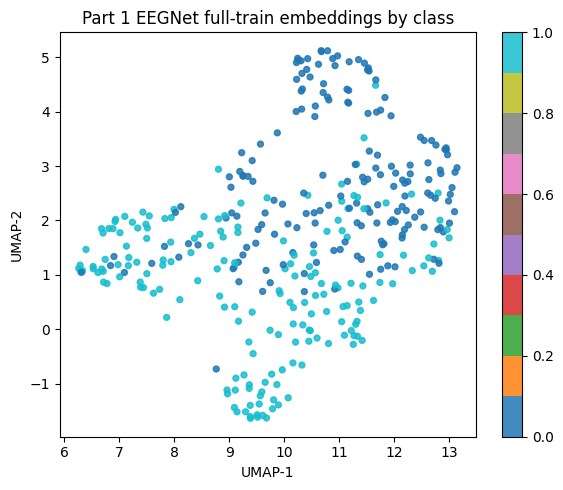

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


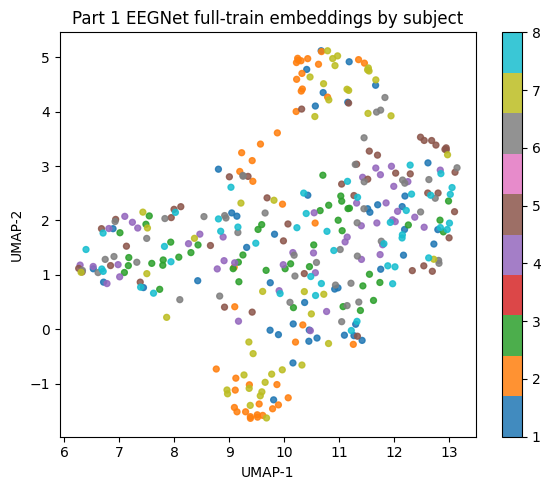

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


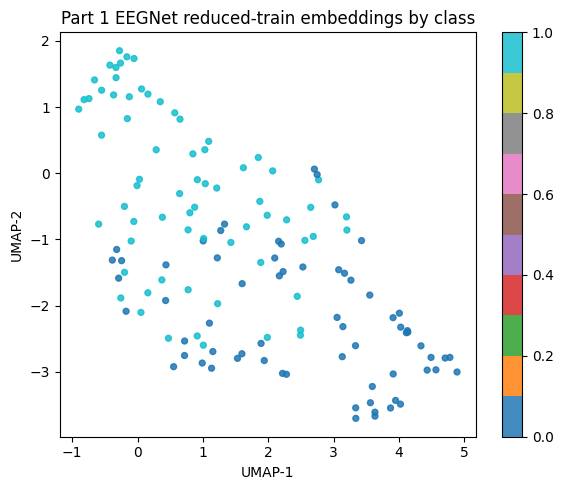

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


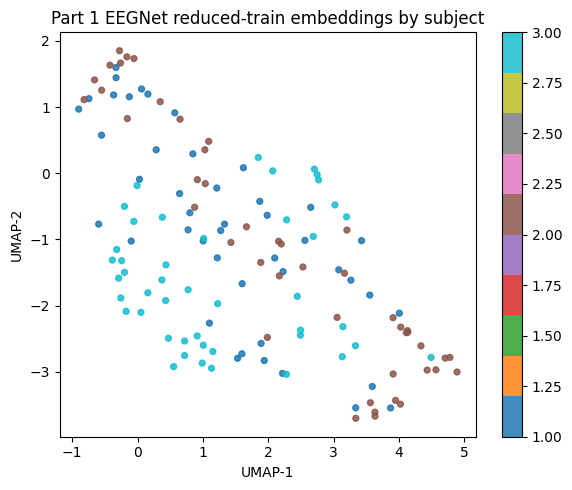

array([[ 0.15864052,  1.1962359 ],
       [ 1.0994265 , -2.2660675 ],
       [ 3.2630975 , -1.6166112 ],
       [-0.74276984,  1.1278857 ],
       [ 1.0041642 , -1.0233508 ],
       [-0.5502196 ,  0.5750684 ],
       [-0.3302768 ,  1.5985712 ],
       [ 3.590303  , -3.2235942 ],
       [ 1.2198284 , -1.2790121 ],
       [ 0.84672326,  0.29301262],
       [ 0.80098367, -0.59769696],
       [ 1.27226   , -0.86612236],
       [ 3.425711  , -1.0183469 ],
       [-0.09741005, -1.0251371 ],
       [ 0.5693175 ,  0.91337925],
       [ 3.5516887 , -1.8417777 ],
       [ 0.64322805, -0.30801144],
       [-0.3281836 ,  1.4443208 ],
       [ 1.3303943 , -0.76885974],
       [ 1.61853   ,  0.08288991],
       [ 1.6000756 , -1.6693217 ],
       [ 2.2172925 , -3.0255487 ],
       [-0.8998829 ,  0.9687386 ],
       [ 0.7730971 , -0.8558867 ],
       [ 3.0764248 , -1.4586383 ],
       [ 1.5965619 , -2.7287145 ],
       [ 1.211596  , -0.22384828],
       [ 1.8697039 , -0.4253277 ],
       [ 1.9381754 ,

In [91]:
def aggregate_results(df, group_cols):
    metrics = [
        "test_balanced_accuracy",
        "class_probe_accuracy",
        "subject_probe_accuracy",
        "class_silhouette",
        "subject_silhouette"
    ]

    rows = []

    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {}
        for col, key in zip(group_cols, keys):
            row[col] = key

        for m in metrics:
            row[f"{m}_mean"] = float(g[m].mean())
            row[f"{m}_std"] = float(g[m].std(ddof=0))
            row[f"{m}_best"] = float(g[m].max())
            row[f"{m}_worst"] = float(g[m].min())

        rows.append(row)

    return pd.DataFrame(rows)


part1_summary = aggregate_results(part1_df, ["experiment_name"])
display(part1_summary)

part1_summary.to_csv("results/part1_summary.csv", index=False)

rep_seed = SEEDS[0]

rep_full = part1_results[("full", rep_seed)]
rep_small = part1_results[("small", rep_seed)]

plot_umap(
    rep_full["Z_train"],
    rep_full["Y_train"],
    "Part 1 EEGNet full-train embeddings by class",
    "results/figures/part1_full_by_class.png"
)

plot_umap(
    rep_full["Z_train"],
    rep_full["S_train"],
    "Part 1 EEGNet full-train embeddings by subject",
    "results/figures/part1_full_by_subject.png"
)

plot_umap(
    rep_small["Z_train"],
    rep_small["Y_train"],
    "Part 1 EEGNet reduced-train embeddings by class",
    "results/figures/part1_reduced_by_class.png"
)

plot_umap(
    rep_small["Z_train"],
    rep_small["S_train"],
    "Part 1 EEGNet reduced-train embeddings by subject",
    "results/figures/part1_reduced_by_subject.png"
)

Part 2: CCSA loss

In [92]:
def ccsa_loss(z, y, subjects):
    """
    Class-Conditional Subject Alignment.

    For each class c:
        align each subject-class centroid mu_{s,c}
        toward the global class centroid mu_c.

    This directly targets the Part 1 failure:
        embeddings preserve subject identity.
    """
    z = torch.nn.functional.normalize(z, p=2, dim=1)

    losses = []

    for c in torch.unique(y):
        class_mask = y == c

        if class_mask.sum() < 2:
            continue

        z_c = z[class_mask]
        s_c = subjects[class_mask]

        mu_c = z_c.mean(dim=0)

        for s in torch.unique(s_c):
            subject_mask = s_c == s

            if subject_mask.sum() < 1:
                continue

            mu_sc = z_c[subject_mask].mean(dim=0)

            # Sum gives the loss enough scale in the embedding space.
            losses.append(torch.sum((mu_sc - mu_c) ** 2))

    if len(losses) == 0:
        return z.new_tensor(0.0)

    return torch.stack(losses).mean()


def train_one_epoch_ccsa(model, loader, optimizer, criterion, beta):
    model.train()

    total_loss = 0.0
    total_ce = 0.0
    total_align = 0.0

    all_preds = []
    all_labels = []

    for X_batch, y_batch, s_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        s_batch = s_batch.to(DEVICE)

        optimizer.zero_grad()

        logits, z = model(X_batch, return_features=True)

        ce = criterion(logits, y_batch)
        align = ccsa_loss(z, y_batch, s_batch)

        loss = ce + beta * align

        loss.backward()
        optimizer.step()
        project_eegnet_max_norm(model)

        total_loss += loss.item() * len(y_batch)
        total_ce += ce.item() * len(y_batch)
        total_align += align.item() * len(y_batch)

        preds = logits.argmax(dim=1).detach().cpu().numpy()
        labels = y_batch.detach().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

    return {
        "loss": total_loss / len(loader.dataset),
        "ce_loss": total_ce / len(loader.dataset),
        "align_loss": total_align / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds)
    }

Part 2: CCSA fixed-epoch run

In [93]:
def run_ccsa(
    train_set: EpochSet,
    test_set: EpochSet,
    beta: float,
    seed: int,
    epochs: int
):
    set_seed(seed)

    n_channels = train_set.X.shape[1]
    n_times = train_set.X.shape[2]

    train_loader = make_loader(
        train_set.X,
        train_set.y,
        train_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    test_loader = make_loader(
        test_set.X,
        test_set.y,
        test_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    dev_loader = make_loader(
        train_set.X,
        train_set.y,
        train_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = EEGNet(
        n_channels=n_channels,
        n_times=n_times
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_bal_acc": [],
        "train_loss": [],
        "ce_loss": [],
        "align_loss": []
    }

    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch_ccsa(
            model,
            train_loader,
            optimizer,
            criterion,
            beta
        )

        history["train_bal_acc"].append(float(train_stats["balanced_accuracy"]))
        history["train_loss"].append(float(train_stats["loss"]))
        history["ce_loss"].append(float(train_stats["ce_loss"]))
        history["align_loss"].append(float(train_stats["align_loss"]))

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"CCSA beta={beta} | seed={seed} | epoch={epoch:03d} | "
                f"train_bal={train_stats['balanced_accuracy']:.3f} | "
                f"CE={train_stats['ce_loss']:.4f} | "
                f"Align={train_stats['align_loss']:.4f}"
            )

    test_stats = evaluate(model, test_loader, criterion)

    Z, Y, S = extract_embeddings(model, dev_loader)

    diag = representation_diagnostics(Z, Y, S)
    probes = linear_probe_scores(Z, Y, S, seed=seed)

    row = {
        "method": "CCSA",
        "beta": float(beta),
        "seed": int(seed),
        "test_accuracy": float(test_stats["accuracy"]),
        "test_balanced_accuracy": float(test_stats["balanced_accuracy"]),
        **diag,
        **probes
    }

    return {
        "row": row,
        "model": model,
        "history": history,
        "Z_train": Z,
        "Y_train": Y,
        "S_train": S
    }

Part 2: CCSA sweep

In [94]:
ccsa_betas = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2,  3.0, 5, 7, 9, 10.0]

ccsa_rows = []
ccsa_results = {}

for seed in SEEDS:
    for beta in ccsa_betas:
        print("\n" + "=" * 90)
        print(f"Part 2 CCSA | beta={beta} | seed={seed}")
        print("=" * 90)

        res = run_ccsa(
            full_train_set,
            test_set,
            beta=beta,
            seed=seed,
            epochs=EPOCHS_SWEEP
        )

        ccsa_rows.append(res["row"])
        ccsa_results[(beta, seed)] = res

ccsa_df = pd.DataFrame(ccsa_rows)
display(ccsa_df)

ccsa_df.to_csv("results/part2_ccsa_raw.csv", index=False)

ccsa_summary = aggregate_results(ccsa_df, ["beta"])
display(ccsa_summary)

ccsa_summary.to_csv("results/part2_ccsa_summary.csv", index=False)


Part 2 CCSA | beta=0.0 | seed=42
CCSA beta=0.0 | seed=42 | epoch=001 | train_bal=0.463 | CE=0.6992 | Align=0.3996
CCSA beta=0.0 | seed=42 | epoch=010 | train_bal=0.607 | CE=0.6698 | Align=0.4574
CCSA beta=0.0 | seed=42 | epoch=020 | train_bal=0.700 | CE=0.6152 | Align=0.4778
CCSA beta=0.0 | seed=42 | epoch=030 | train_bal=0.706 | CE=0.5869 | Align=0.4775
CCSA beta=0.0 | seed=42 | epoch=040 | train_bal=0.741 | CE=0.5475 | Align=0.4963
CCSA beta=0.0 | seed=42 | epoch=050 | train_bal=0.769 | CE=0.4947 | Align=0.4801
CCSA beta=0.0 | seed=42 | epoch=060 | train_bal=0.806 | CE=0.4320 | Align=0.4829

Part 2 CCSA | beta=0.2 | seed=42
CCSA beta=0.2 | seed=42 | epoch=001 | train_bal=0.469 | CE=0.6990 | Align=0.3978
CCSA beta=0.2 | seed=42 | epoch=010 | train_bal=0.604 | CE=0.6732 | Align=0.3877
CCSA beta=0.2 | seed=42 | epoch=020 | train_bal=0.686 | CE=0.6474 | Align=0.3612
CCSA beta=0.2 | seed=42 | epoch=030 | train_bal=0.690 | CE=0.6153 | Align=0.3597
CCSA beta=0.2 | seed=42 | epoch=040 | tra

,method,beta,seed,test_accuracy,test_balanced_accuracy,class_silhouette,subject_silhouette,class_probe_accuracy,subject_probe_accuracy,subject_chance_level
0,CCSA,0.0,42,0.555556,0.557312,0.088467,-0.048322,0.916667,0.583333,0.125
1,CCSA,0.2,42,0.422222,0.423913,0.066999,-0.077919,0.851852,0.324074,0.125
2,CCSA,0.3,42,0.422222,0.424407,0.073651,-0.079945,0.842593,0.398148,0.125
3,CCSA,0.4,42,0.422222,0.424407,0.072254,-0.075020,0.777778,0.342593,0.125
4,CCSA,0.5,42,0.444444,0.446640,0.071525,-0.066526,0.805556,0.342593,0.125
5,CCSA,0.6,42,0.488889,0.491601,0.072146,-0.062867,0.824074,0.379630,0.125
6,CCSA,0.7,42,0.477778,0.480237,0.071656,-0.061489,0.833333,0.259259,0.125
7,CCSA,0.8,42,0.511111,0.512846,0.069458,-0.060329,0.833333,0.268519,0.125
8,CCSA,0.9,42,0.466667,0.468874,0.066036,-0.059059,0.814815,0.296296,0.125
9,CCSA,1.0,42,0.466667,0.469368,0.062926,-0.056746,0.796296,0.370370,0.125


,beta,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_balanced_accuracy_best,test_balanced_accuracy_worst,class_probe_accuracy_mean,class_probe_accuracy_std,class_probe_accuracy_best,class_probe_accuracy_worst,subject_probe_accuracy_mean,...,subject_probe_accuracy_best,subject_probe_accuracy_worst,class_silhouette_mean,class_silhouette_std,class_silhouette_best,class_silhouette_worst,subject_silhouette_mean,subject_silhouette_std,subject_silhouette_best,subject_silhouette_worst
0,0.0,0.591568,0.025797,0.619565,0.557312,0.873457,0.031475,0.916667,0.842593,0.598765,...,0.620370,0.583333,0.111277,0.018748,0.134386,0.088467,-0.070352,0.020372,-0.048322,-0.097445
1,0.2,0.506094,0.058114,0.547925,0.423913,0.808642,0.030554,0.851852,0.787037,0.444444,...,0.509259,0.324074,0.061912,0.006545,0.066999,0.052672,-0.069332,0.006086,-0.064536,-0.077919
2,0.3,0.512846,0.068533,0.591403,0.424407,0.811728,0.023097,0.842593,0.787037,0.447531,...,0.518519,0.398148,0.074251,0.002362,0.077396,0.071705,-0.079722,0.009985,-0.067384,-0.091838
3,0.4,0.499177,0.052908,0.539032,0.424407,0.790123,0.011548,0.805556,0.777778,0.379630,...,0.398148,0.342593,0.076885,0.006149,0.085575,0.072254,-0.084205,0.017900,-0.068368,-0.109226
4,0.5,0.516798,0.055023,0.581028,0.446640,0.808642,0.026550,0.842593,0.777778,0.379630,...,0.398148,0.342593,0.077665,0.007387,0.088055,0.071525,-0.087408,0.027528,-0.066526,-0.126303
5,0.6,0.519104,0.048634,0.587451,0.478261,0.808642,0.028622,0.833333,0.768519,0.388889,...,0.398148,0.379630,0.076433,0.005275,0.083863,0.072146,-0.084402,0.026511,-0.062867,-0.121748
6,0.7,0.518775,0.048348,0.586957,0.480237,0.833333,0.037801,0.879630,0.787037,0.395062,...,0.472222,0.259259,0.073454,0.001430,0.075156,0.071656,-0.080190,0.025495,-0.061489,-0.116237
7,0.8,0.536726,0.027403,0.575099,0.512846,0.836420,0.049189,0.898148,0.777778,0.373457,...,0.462963,0.268519,0.070293,0.002562,0.073763,0.067658,-0.077649,0.026190,-0.057955,-0.114662
8,0.9,0.522398,0.043569,0.575593,0.468874,0.811728,0.041638,0.861111,0.759259,0.370370,...,0.490741,0.296296,0.068551,0.003456,0.073437,0.066036,-0.076488,0.028707,-0.053447,-0.116957
9,1.0,0.533103,0.051839,0.596344,0.469368,0.787037,0.042093,0.833333,0.731481,0.382716,...,0.462963,0.314815,0.062703,0.006417,0.070448,0.054733,-0.076339,0.030717,-0.052559,-0.119713


Part 2 plot and UMAP

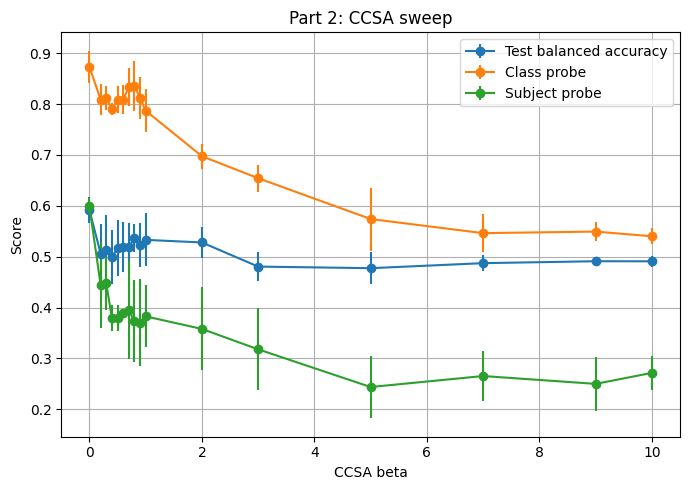

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


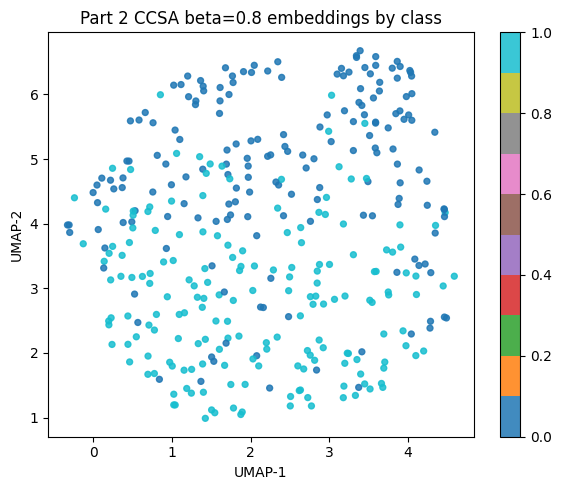

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


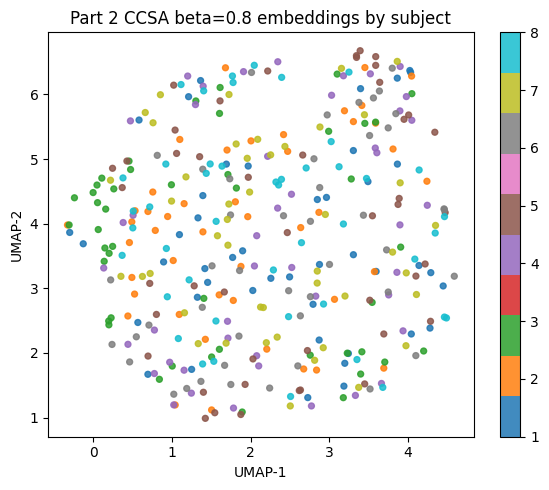

In [95]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    ccsa_summary["beta"],
    ccsa_summary["test_balanced_accuracy_mean"],
    yerr=ccsa_summary["test_balanced_accuracy_std"],
    marker="o",
    label="Test balanced accuracy"
)

plt.errorbar(
    ccsa_summary["beta"],
    ccsa_summary["class_probe_accuracy_mean"],
    yerr=ccsa_summary["class_probe_accuracy_std"],
    marker="o",
    label="Class probe"
)

plt.errorbar(
    ccsa_summary["beta"],
    ccsa_summary["subject_probe_accuracy_mean"],
    yerr=ccsa_summary["subject_probe_accuracy_std"],
    marker="o",
    label="Subject probe"
)

plt.xlabel("CCSA beta")
plt.ylabel("Score")
plt.title("Part 2: CCSA sweep")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/figures/part2_ccsa_sweep.png", dpi=200)
plt.show()


# Representative UMAP uses predeclared beta, not test-selected beta.
if MAIN_CCSA_BETA in ccsa_betas:
    rep_ccsa = ccsa_results[(MAIN_CCSA_BETA, SEEDS[0])]

    plot_umap(
        rep_ccsa["Z_train"],
        rep_ccsa["Y_train"],
        f"Part 2 CCSA beta={MAIN_CCSA_BETA} embeddings by class",
        "results/figures/part2_ccsa_by_class.png"
    )

    plot_umap(
        rep_ccsa["Z_train"],
        rep_ccsa["S_train"],
        f"Part 2 CCSA beta={MAIN_CCSA_BETA} embeddings by subject",
        "results/figures/part2_ccsa_by_subject.png"
    )

Part 3: AP-MRG functions

In [96]:
MRG_BANDS = [
    ("theta_4_8", 4, 8),
    ("mu_8_12", 8, 12),
    ("low_beta_12_16", 12, 16),
    ("mid_beta_16_24", 16, 24),
    ("high_beta_24_38", 24, 38),
]


def bandpass_epochs(X, fs, low, high, order=4):
    nyq = fs / 2
    high = min(high, nyq - 1.0)

    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return sosfiltfilt(sos, X, axis=-1)


def band_logpower(X_band):
    return np.log(np.mean(X_band ** 2, axis=-1) + 1e-8)


def class_discriminability(F, y):
    F0 = F[y == 0]
    F1 = F[y == 1]

    mu0 = F0.mean(axis=0)
    mu1 = F1.mean(axis=0)

    std0 = F0.std(axis=0)
    std1 = F1.std(axis=0)

    d = np.abs(mu1 - mu0) / (0.5 * (std0 + std1) + 1e-6)

    return float(np.mean(d))


def subject_nuisance(F, subjects):
    unique_subjects = np.unique(subjects)

    subject_means = []

    for s in unique_subjects:
        subject_means.append(F[subjects == s].mean(axis=0))

    subject_means = np.stack(subject_means, axis=0)

    between = np.var(subject_means, axis=0)
    total = np.var(F, axis=0) + 1e-6

    return float(np.mean(between / total))


def softmax_np(x, temperature=1.0):
    x = np.asarray(x, dtype=np.float64)
    x = x / temperature
    x = x - np.max(x)
    e = np.exp(x)

    return e / (np.sum(e) + 1e-12)


def compute_mrg_weights(X_train, y_train, subjects_train, fs=160, alpha=1.0):
    """
    AP-MRG reliability:

        R_b = class_discriminability_b / subject_nuisance_b

    A useful band should separate classes while not being dominated by subject identity.
    """
    rows = []
    reliability = []

    for band_name, low, high in MRG_BANDS:
        Xb = bandpass_epochs(X_train, fs=fs, low=low, high=high)
        F = band_logpower(Xb)

        D = class_discriminability(F, y_train)
        S = subject_nuisance(F, subjects_train)

        R = D / ((S + 1e-6) ** alpha)

        rows.append({
            "band": band_name,
            "low_hz": low,
            "high_hz": high,
            "class_discriminability": D,
            "subject_nuisance": S,
            "raw_reliability": R
        })

        reliability.append(R)

    reliability = np.asarray(reliability)

    normalized = (reliability - reliability.mean()) / (reliability.std() + 1e-6)
    weights = softmax_np(normalized, temperature=1.0)

    for i in range(len(rows)):
        rows[i]["normalized_reliability"] = float(normalized[i])
        rows[i]["mrg_weight"] = float(weights[i])

    return weights, pd.DataFrame(rows)


def apply_mrg(X, weights, fs=160):
    X_out = np.zeros_like(X)

    for w, (_, low, high) in zip(weights, MRG_BANDS):
        Xb = bandpass_epochs(X, fs=fs, low=low, high=high)
        X_out += w * Xb

    return per_trial_zscore(X_out)


def mix_original_mrg(X_original, X_mrg, lam):
    if lam == 0.0:
        return X_original.copy()
    if lam == 1.0:
        return X_mrg.copy()

    X_mix = (1.0 - lam) * X_original + lam * X_mrg
    return per_trial_zscore(X_mix)

Precompute AP-MRG weights and signals

In [97]:
# Compute AP-MRG weights using only assigned training subjects 1-8.
# No test subject is used in the weighting calculation.

mrg_weights, mrg_band_table = compute_mrg_weights(
    full_train_set.X,
    full_train_set.y,
    full_train_set.subjects,
    fs=RESAMPLE_RATE,
    alpha=1.0
)

display(mrg_band_table)

mrg_band_table.to_csv(
    "results/part3_mrg_band_table.csv",
    index=False
)

X_train_mrg = apply_mrg(
    full_train_set.X,
    mrg_weights,
    fs=RESAMPLE_RATE
)

X_test_mrg = apply_mrg(
    test_set.X,
    mrg_weights,
    fs=RESAMPLE_RATE
)

print("MRG weights:", mrg_weights)
print("X_train_mrg:", X_train_mrg.shape)
print("X_test_mrg:", X_test_mrg.shape)

,band,low_hz,high_hz,class_discriminability,subject_nuisance,raw_reliability,normalized_reliability,mrg_weight
0,theta_4_8,4,8,0.092341,0.352907,0.261656,0.155743,0.125810
1,mu_8_12,8,12,0.045867,0.560520,0.081829,-0.816732,0.047574
2,low_beta_12_16,12,16,0.214249,0.368362,0.581624,1.886077,0.709886
3,mid_beta_16_24,16,24,0.060702,0.491197,0.123579,-0.590955,0.059625
4,high_beta_24_38,24,38,0.078846,0.682093,0.115595,-0.634132,0.057105


MRG weights: [0.12580967 0.0475744  0.70988591 0.05962482 0.0571052 ]
X_train_mrg: (360, 64, 321)
X_test_mrg: (90, 64, 321)


Part 3 AP-MRG fixed-epoch run

In [98]:
def run_ap_mrg(
    train_set: EpochSet,
    test_set: EpochSet,
    X_train_mrg,
    X_test_mrg,
    lam: float,
    seed: int,
    epochs: int
):
    set_seed(seed)

    Xtr = mix_original_mrg(train_set.X, X_train_mrg, lam)
    Xte = mix_original_mrg(test_set.X, X_test_mrg, lam)

    n_channels = Xtr.shape[1]
    n_times = Xtr.shape[2]

    train_loader = make_loader(
        Xtr,
        train_set.y,
        train_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    test_loader = make_loader(
        Xte,
        test_set.y,
        test_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    dev_loader = make_loader(
        Xtr,
        train_set.y,
        train_set.subjects,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = EEGNet(
        n_channels=n_channels,
        n_times=n_times
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_bal_acc": [],
        "train_loss": []
    }

    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        history["train_bal_acc"].append(float(train_stats["balanced_accuracy"]))
        history["train_loss"].append(float(train_stats["loss"]))

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"AP-MRG lambda={lam} | seed={seed} | epoch={epoch:03d} | "
                f"train_bal={train_stats['balanced_accuracy']:.3f} | "
                f"train_loss={train_stats['loss']:.4f}"
            )

    test_stats = evaluate(model, test_loader, criterion)

    Z, Y, S = extract_embeddings(model, dev_loader)

    diag = representation_diagnostics(Z, Y, S)
    probes = linear_probe_scores(Z, Y, S, seed=seed)

    row = {
        "method": "AP-MRG",
        "lambda": float(lam),
        "seed": int(seed),
        "test_accuracy": float(test_stats["accuracy"]),
        "test_balanced_accuracy": float(test_stats["balanced_accuracy"]),
        **diag,
        **probes
    }

    return {
        "row": row,
        "model": model,
        "history": history,
        "Z_train": Z,
        "Y_train": Y,
        "S_train": S
    }

Part 3 AP-MRG sweep

In [99]:
apmrg_lambdas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

apmrg_rows = []
apmrg_results = {}

for seed in SEEDS:
    for lam in apmrg_lambdas:
        print("\n" + "=" * 90)
        print(f"Part 3 AP-MRG | lambda={lam} | seed={seed}")
        print("=" * 90)

        res = run_ap_mrg(
            full_train_set,
            test_set,
            X_train_mrg,
            X_test_mrg,
            lam=lam,
            seed=seed,
            epochs=EPOCHS_SWEEP
        )

        apmrg_rows.append(res["row"])
        apmrg_results[(lam, seed)] = res

apmrg_df = pd.DataFrame(apmrg_rows)
display(apmrg_df)

apmrg_df.to_csv("results/part3_apmrg_raw.csv", index=False)

apmrg_summary = aggregate_results(apmrg_df, ["lambda"])
display(apmrg_summary)

apmrg_summary.to_csv("results/part3_apmrg_summary.csv", index=False)


Part 3 AP-MRG | lambda=0.0 | seed=42
AP-MRG lambda=0.0 | seed=42 | epoch=001 | train_bal=0.463 | train_loss=0.6992
AP-MRG lambda=0.0 | seed=42 | epoch=010 | train_bal=0.607 | train_loss=0.6698
AP-MRG lambda=0.0 | seed=42 | epoch=020 | train_bal=0.700 | train_loss=0.6152
AP-MRG lambda=0.0 | seed=42 | epoch=030 | train_bal=0.706 | train_loss=0.5869
AP-MRG lambda=0.0 | seed=42 | epoch=040 | train_bal=0.741 | train_loss=0.5475
AP-MRG lambda=0.0 | seed=42 | epoch=050 | train_bal=0.769 | train_loss=0.4947
AP-MRG lambda=0.0 | seed=42 | epoch=060 | train_bal=0.806 | train_loss=0.4320

Part 3 AP-MRG | lambda=0.1 | seed=42
AP-MRG lambda=0.1 | seed=42 | epoch=001 | train_bal=0.461 | train_loss=0.6988
AP-MRG lambda=0.1 | seed=42 | epoch=010 | train_bal=0.623 | train_loss=0.6704
AP-MRG lambda=0.1 | seed=42 | epoch=020 | train_bal=0.689 | train_loss=0.6176
AP-MRG lambda=0.1 | seed=42 | epoch=030 | train_bal=0.711 | train_loss=0.5869
AP-MRG lambda=0.1 | seed=42 | epoch=040 | train_bal=0.736 | train_

,method,lambda,seed,test_accuracy,test_balanced_accuracy,class_silhouette,subject_silhouette,class_probe_accuracy,subject_probe_accuracy,subject_chance_level
0,AP-MRG,0.0,42,0.555556,0.557312,0.088467,-0.048322,0.916667,0.583333,0.125
1,AP-MRG,0.1,42,0.544444,0.547925,0.080011,-0.048690,0.907407,0.583333,0.125
2,AP-MRG,0.2,42,0.555556,0.557806,0.083396,-0.052284,0.907407,0.592593,0.125
3,AP-MRG,0.3,42,0.544444,0.544960,0.100330,-0.052927,0.861111,0.611111,0.125
4,AP-MRG,0.4,42,0.533333,0.531621,0.125722,-0.053060,0.879630,0.583333,0.125
5,AP-MRG,0.5,42,0.555556,0.554842,0.143973,-0.056036,0.898148,0.555556,0.125
6,AP-MRG,0.6,42,0.500000,0.497530,0.170481,-0.063981,0.879630,0.509259,0.125
7,AP-MRG,0.7,42,0.533333,0.532609,0.151238,-0.076811,0.916667,0.555556,0.125
8,AP-MRG,0.8,42,0.533333,0.532609,0.141623,-0.082966,0.898148,0.490741,0.125
9,AP-MRG,0.9,42,0.522222,0.522233,0.138933,-0.085873,0.888889,0.472222,0.125


,lambda,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_balanced_accuracy_best,test_balanced_accuracy_worst,class_probe_accuracy_mean,class_probe_accuracy_std,class_probe_accuracy_best,class_probe_accuracy_worst,subject_probe_accuracy_mean,...,subject_probe_accuracy_best,subject_probe_accuracy_worst,class_silhouette_mean,class_silhouette_std,class_silhouette_best,class_silhouette_worst,subject_silhouette_mean,subject_silhouette_std,subject_silhouette_best,subject_silhouette_worst
0,0.0,0.591568,0.025797,0.619565,0.557312,0.873457,0.031475,0.916667,0.842593,0.598765,...,0.620370,0.583333,0.111277,0.018748,0.134386,0.088467,-0.070352,0.020372,-0.048322,-0.097445
1,0.1,0.583333,0.028452,0.617589,0.547925,0.885802,0.030554,0.907407,0.842593,0.574074,...,0.601852,0.537037,0.109280,0.022472,0.134639,0.080011,-0.074385,0.019854,-0.048690,-0.097036
2,0.2,0.568347,0.018510,0.594368,0.552866,0.885802,0.019026,0.907407,0.861111,0.561728,...,0.629630,0.462963,0.108427,0.018501,0.127540,0.083396,-0.070241,0.016948,-0.052284,-0.092967
3,0.3,0.571640,0.021988,0.598814,0.544960,0.870370,0.013095,0.888889,0.861111,0.555556,...,0.611111,0.490741,0.111729,0.012876,0.129726,0.100330,-0.070398,0.014900,-0.052927,-0.089337
4,0.4,0.538373,0.008523,0.550395,0.531621,0.891975,0.011548,0.907407,0.879630,0.540123,...,0.583333,0.453704,0.137241,0.020422,0.165937,0.120065,-0.075975,0.017961,-0.053060,-0.096925
5,0.5,0.561265,0.009435,0.574605,0.554348,0.882716,0.057742,0.944444,0.805556,0.524691,...,0.555556,0.490741,0.149874,0.023346,0.180956,0.124692,-0.079932,0.018523,-0.056036,-0.101173
6,0.6,0.512187,0.020380,0.541008,0.497530,0.876543,0.056743,0.944444,0.805556,0.506173,...,0.537037,0.472222,0.162207,0.019612,0.180996,0.135144,-0.083645,0.015028,-0.063981,-0.100460
7,0.7,0.519433,0.015920,0.532609,0.497036,0.895062,0.058723,0.953704,0.814815,0.524691,...,0.555556,0.472222,0.160449,0.014764,0.181283,0.148827,-0.088605,0.009089,-0.076811,-0.098929
8,0.8,0.526186,0.013495,0.538538,0.507411,0.901235,0.034091,0.944444,0.861111,0.481481,...,0.546296,0.407407,0.157201,0.016516,0.180063,0.141623,-0.092664,0.006872,-0.082966,-0.098042
9,0.9,0.497365,0.031405,0.522233,0.453063,0.898148,0.034645,0.944444,0.861111,0.447531,...,0.472222,0.398148,0.156291,0.014263,0.173868,0.138933,-0.092855,0.005537,-0.085873,-0.099417


Part 3 plot and UMAP

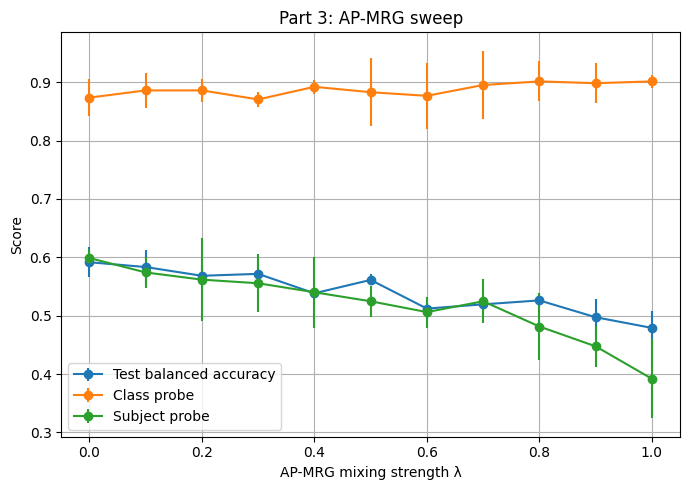

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


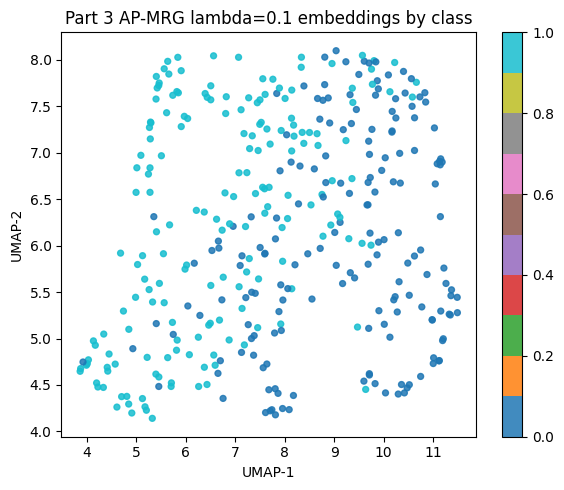

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


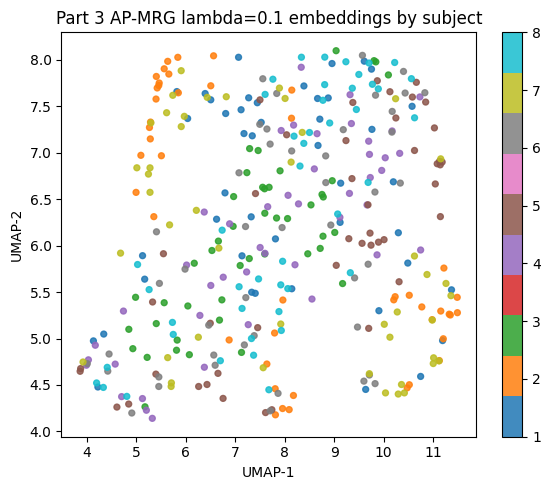

In [100]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    apmrg_summary["lambda"],
    apmrg_summary["test_balanced_accuracy_mean"],
    yerr=apmrg_summary["test_balanced_accuracy_std"],
    marker="o",
    label="Test balanced accuracy"
)

plt.errorbar(
    apmrg_summary["lambda"],
    apmrg_summary["class_probe_accuracy_mean"],
    yerr=apmrg_summary["class_probe_accuracy_std"],
    marker="o",
    label="Class probe"
)

plt.errorbar(
    apmrg_summary["lambda"],
    apmrg_summary["subject_probe_accuracy_mean"],
    yerr=apmrg_summary["subject_probe_accuracy_std"],
    marker="o",
    label="Subject probe"
)

plt.xlabel("AP-MRG mixing strength λ")
plt.ylabel("Score")
plt.title("Part 3: AP-MRG sweep")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/figures/part3_apmrg_sweep.png", dpi=200)
plt.show()


# Representative UMAP uses predeclared adaptive lambda.
# lambda=1 is full replacement and should be treated as an ablation.
if MAIN_APMRG_LAMBDA in apmrg_lambdas:
    rep_apmrg = apmrg_results[(MAIN_APMRG_LAMBDA, SEEDS[0])]

    plot_umap(
        rep_apmrg["Z_train"],
        rep_apmrg["Y_train"],
        f"Part 3 AP-MRG lambda={MAIN_APMRG_LAMBDA} embeddings by class",
        "results/figures/part3_apmrg_by_class.png"
    )

    plot_umap(
        rep_apmrg["Z_train"],
        rep_apmrg["S_train"],
        f"Part 3 AP-MRG lambda={MAIN_APMRG_LAMBDA} embeddings by subject",
        "results/figures/part3_apmrg_by_subject.png"
    )

Compact tables

In [101]:
part1_compact = part1_summary[
    [
        "experiment_name",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_balanced_accuracy_best",
        "test_balanced_accuracy_worst",
        "class_probe_accuracy_mean",
        "subject_probe_accuracy_mean"
    ]
].copy()

part2_compact = ccsa_summary[
    [
        "beta",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_balanced_accuracy_best",
        "test_balanced_accuracy_worst",
        "class_probe_accuracy_mean",
        "subject_probe_accuracy_mean"
    ]
].copy()

part3_compact = apmrg_summary[
    [
        "lambda",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_balanced_accuracy_best",
        "test_balanced_accuracy_worst",
        "class_probe_accuracy_mean",
        "subject_probe_accuracy_mean"
    ]
].copy()

print("PART 1 COMPACT")
display(part1_compact)

print("PART 2 CCSA COMPACT")
display(part2_compact)

print("PART 3 AP-MRG COMPACT")
display(part3_compact)

part1_compact.to_csv("results/part1_compact.csv", index=False)
part2_compact.to_csv("results/part2_ccsa_compact.csv", index=False)
part3_compact.to_csv("results/part3_apmrg_compact.csv", index=False)

PART 1 COMPACT


,experiment_name,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_balanced_accuracy_best,test_balanced_accuracy_worst,class_probe_accuracy_mean,subject_probe_accuracy_mean
0,Part1_EEGNet_full_train_1_to_8,0.591568,0.025797,0.619565,0.557312,0.873457,0.598765
1,Part1_EEGNet_reduced_train_1_to_3,0.556489,0.023416,0.589427,0.537055,0.804878,0.780488


PART 2 CCSA COMPACT


,beta,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_balanced_accuracy_best,test_balanced_accuracy_worst,class_probe_accuracy_mean,subject_probe_accuracy_mean
0,0.0,0.591568,0.025797,0.619565,0.557312,0.873457,0.598765
1,0.2,0.506094,0.058114,0.547925,0.423913,0.808642,0.444444
2,0.3,0.512846,0.068533,0.591403,0.424407,0.811728,0.447531
3,0.4,0.499177,0.052908,0.539032,0.424407,0.790123,0.379630
4,0.5,0.516798,0.055023,0.581028,0.446640,0.808642,0.379630
5,0.6,0.519104,0.048634,0.587451,0.478261,0.808642,0.388889
6,0.7,0.518775,0.048348,0.586957,0.480237,0.833333,0.395062
7,0.8,0.536726,0.027403,0.575099,0.512846,0.836420,0.373457
8,0.9,0.522398,0.043569,0.575593,0.468874,0.811728,0.370370
9,1.0,0.533103,0.051839,0.596344,0.469368,0.787037,0.382716


PART 3 AP-MRG COMPACT


,lambda,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_balanced_accuracy_best,test_balanced_accuracy_worst,class_probe_accuracy_mean,subject_probe_accuracy_mean
0,0.0,0.591568,0.025797,0.619565,0.557312,0.873457,0.598765
1,0.1,0.583333,0.028452,0.617589,0.547925,0.885802,0.574074
2,0.2,0.568347,0.018510,0.594368,0.552866,0.885802,0.561728
3,0.3,0.571640,0.021988,0.598814,0.544960,0.870370,0.555556
4,0.4,0.538373,0.008523,0.550395,0.531621,0.891975,0.540123
5,0.5,0.561265,0.009435,0.574605,0.554348,0.882716,0.524691
6,0.6,0.512187,0.020380,0.541008,0.497530,0.876543,0.506173
7,0.7,0.519433,0.015920,0.532609,0.497036,0.895062,0.524691
8,0.8,0.526186,0.013495,0.538538,0.507411,0.901235,0.481481
9,0.9,0.497365,0.031405,0.522233,0.453063,0.898148,0.447531


In [102]:
def get_histories(result_dict, keys):
    histories = []

    for key in keys:
        if key in result_dict:
            histories.append(result_dict[key]["history"])

    return histories


def plot_metric_all_seeds(histories, metric, title, filename):
    """
    Plot epoch-wise curves for all seeds plus mean ± std.

    Example metric:
        train_bal_acc
        train_loss
        align_loss
        ce_loss
    """
    curves = []

    for h in histories:
        if metric in h:
            curves.append(np.asarray(h[metric], dtype=float))

    if len(curves) == 0:
        print(f"No curves found for metric: {metric}")
        return

    min_len = min(len(c) for c in curves)
    curves = np.stack([c[:min_len] for c in curves], axis=0)

    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)

    epochs = np.arange(1, min_len + 1)

    plt.figure(figsize=(7.2, 4.6))

    # Individual seed curves
    for i in range(curves.shape[0]):
        plt.plot(epochs, curves[i], alpha=0.35, linewidth=1.2, label=f"Seed {i+1}")

    # Mean curve
    plt.plot(epochs, mean_curve, linewidth=2.8, label="Mean")

    # Uncertainty band
    plt.fill_between(
        epochs,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.18,
        label="±1 std"
    )

    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " "))
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=220)
    plt.show()

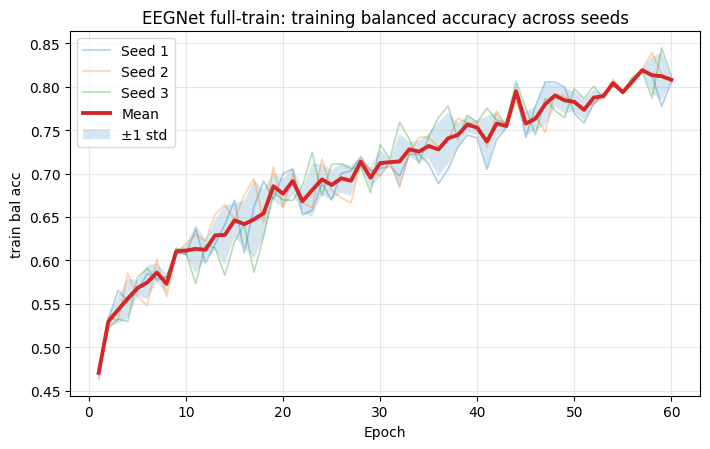

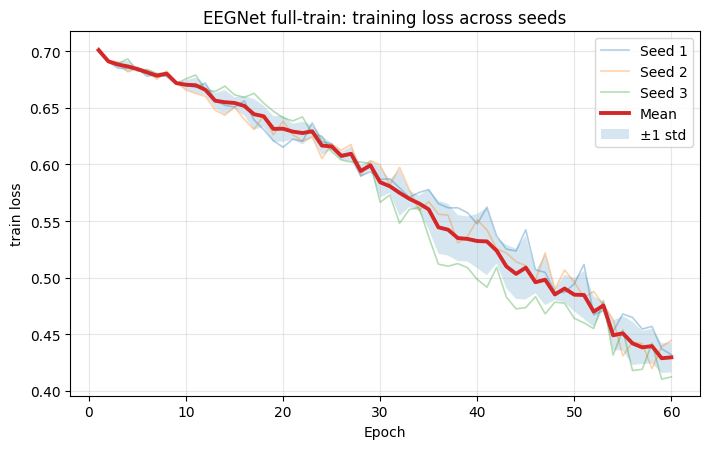

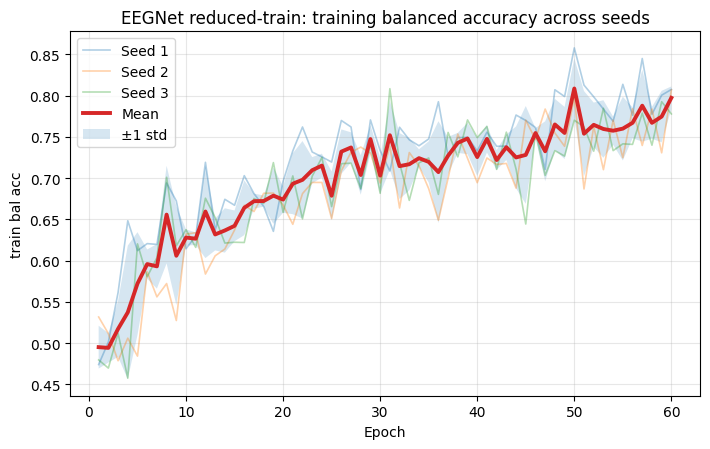

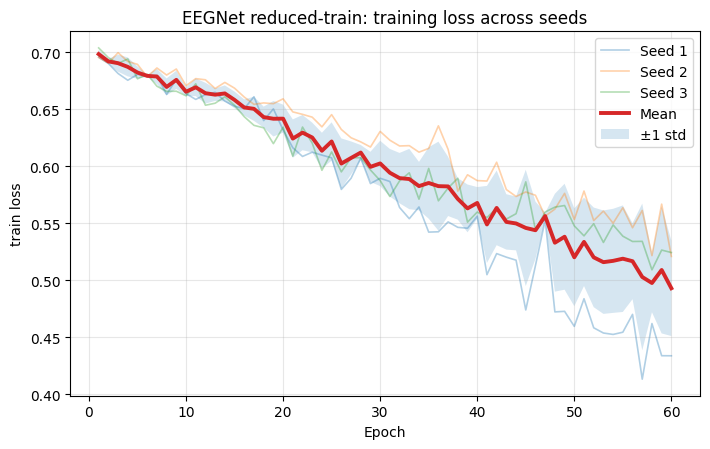

In [103]:
# Part 1 full EEGNet
full_keys = [("full", seed) for seed in SEEDS]
full_histories = get_histories(part1_results, full_keys)

plot_metric_all_seeds(
    full_histories,
    metric="train_bal_acc",
    title="EEGNet full-train: training balanced accuracy across seeds",
    filename="results/figures/curves_part1_full_train_bal_acc_all_seeds.png"
)

plot_metric_all_seeds(
    full_histories,
    metric="train_loss",
    title="EEGNet full-train: training loss across seeds",
    filename="results/figures/curves_part1_full_train_loss_all_seeds.png"
)


# Part 1 reduced EEGNet
small_keys = [("small", seed) for seed in SEEDS]
small_histories = get_histories(part1_results, small_keys)

plot_metric_all_seeds(
    small_histories,
    metric="train_bal_acc",
    title="EEGNet reduced-train: training balanced accuracy across seeds",
    filename="results/figures/curves_part1_reduced_train_bal_acc_all_seeds.png"
)

plot_metric_all_seeds(
    small_histories,
    metric="train_loss",
    title="EEGNet reduced-train: training loss across seeds",
    filename="results/figures/curves_part1_reduced_train_loss_all_seeds.png"
)

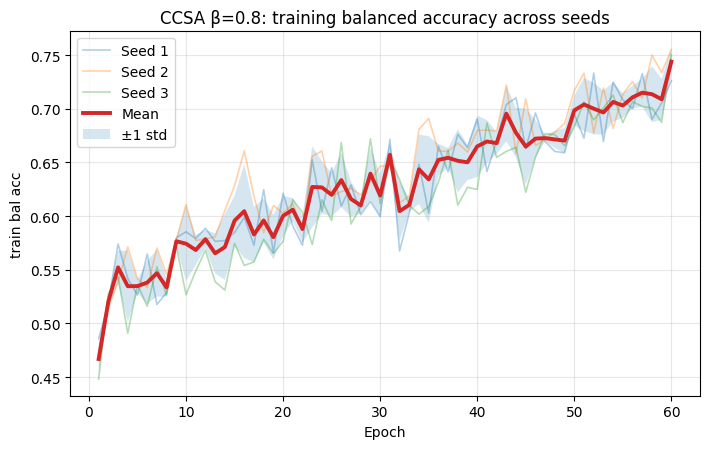

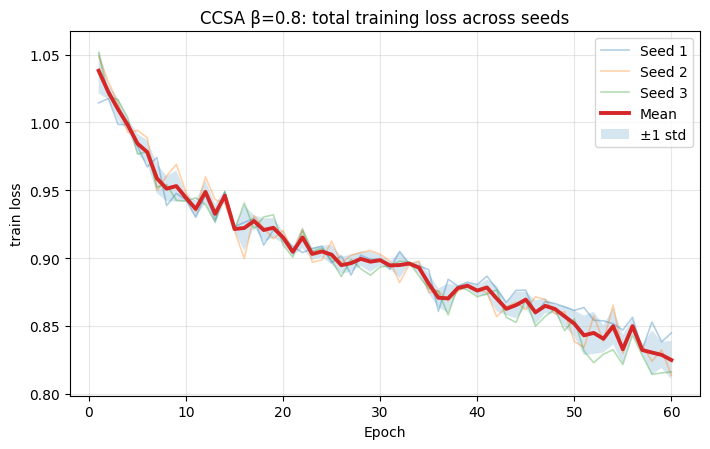

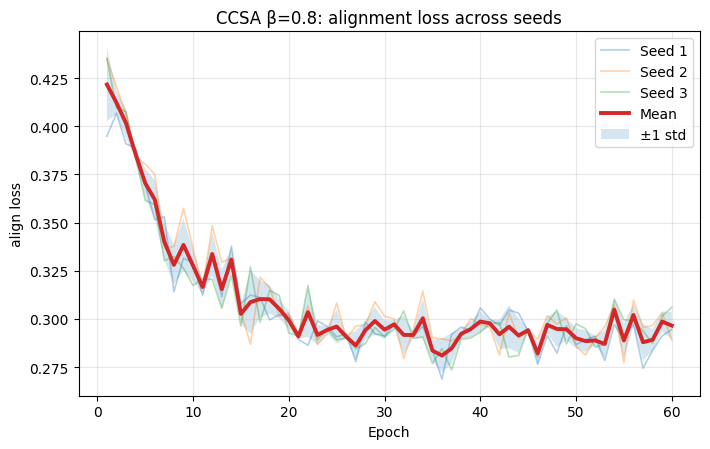

In [104]:
MAIN_CCSA_BETA = 0.8

ccsa_keys = [(MAIN_CCSA_BETA, seed) for seed in SEEDS]
ccsa_histories = get_histories(ccsa_results, ccsa_keys)

plot_metric_all_seeds(
    ccsa_histories,
    metric="train_bal_acc",
    title=f"CCSA β={MAIN_CCSA_BETA}: training balanced accuracy across seeds",
    filename=f"results/figures/curves_ccsa_beta_{MAIN_CCSA_BETA}_train_bal_acc_all_seeds.png"
)

plot_metric_all_seeds(
    ccsa_histories,
    metric="train_loss",
    title=f"CCSA β={MAIN_CCSA_BETA}: total training loss across seeds",
    filename=f"results/figures/curves_ccsa_beta_{MAIN_CCSA_BETA}_train_loss_all_seeds.png"
)

plot_metric_all_seeds(
    ccsa_histories,
    metric="align_loss",
    title=f"CCSA β={MAIN_CCSA_BETA}: alignment loss across seeds",
    filename=f"results/figures/curves_ccsa_beta_{MAIN_CCSA_BETA}_align_loss_all_seeds.png"
)

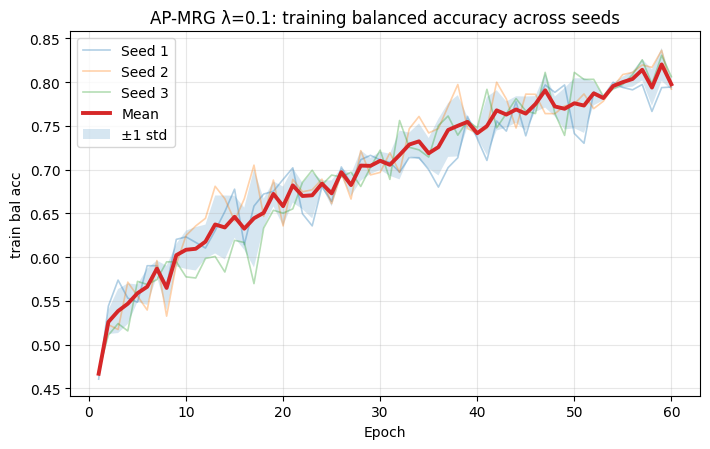

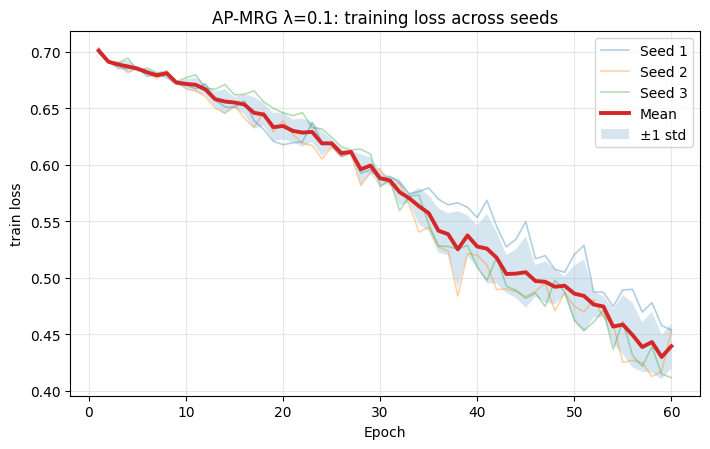

In [105]:
MAIN_APMRG_LAMBDA = 0.1

apmrg_keys = [(MAIN_APMRG_LAMBDA, seed) for seed in SEEDS]
apmrg_histories = get_histories(apmrg_results, apmrg_keys)

plot_metric_all_seeds(
    apmrg_histories,
    metric="train_bal_acc",
    title=f"AP-MRG λ={MAIN_APMRG_LAMBDA}: training balanced accuracy across seeds",
    filename=f"results/figures/curves_apmrg_lambda_{MAIN_APMRG_LAMBDA}_train_bal_acc_all_seeds.png"
)

plot_metric_all_seeds(
    apmrg_histories,
    metric="train_loss",
    title=f"AP-MRG λ={MAIN_APMRG_LAMBDA}: training loss across seeds",
    filename=f"results/figures/curves_apmrg_lambda_{MAIN_APMRG_LAMBDA}_train_loss_all_seeds.png"
)

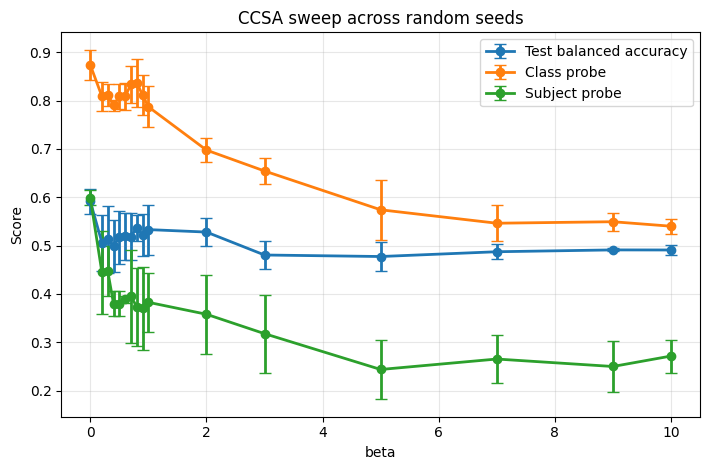

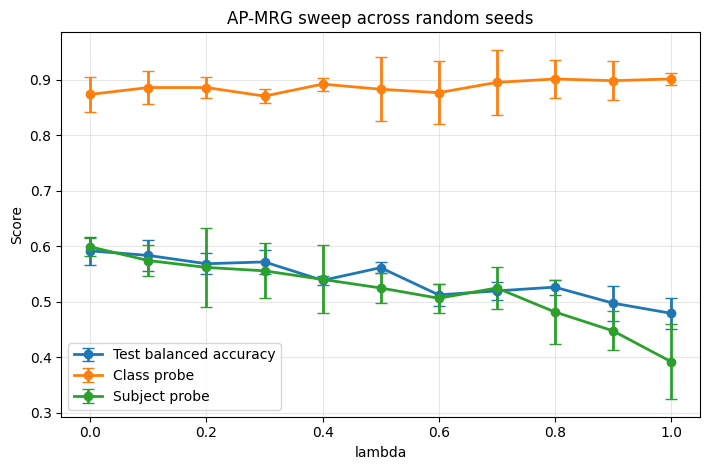

In [106]:
def plot_sweep_errorbars(df, x_col, title, filename):
    plt.figure(figsize=(7.2, 4.8))

    plt.errorbar(
        df[x_col],
        df["test_balanced_accuracy_mean"],
        yerr=df["test_balanced_accuracy_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Test balanced accuracy"
    )

    plt.errorbar(
        df[x_col],
        df["class_probe_accuracy_mean"],
        yerr=df["class_probe_accuracy_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Class probe"
    )

    plt.errorbar(
        df[x_col],
        df["subject_probe_accuracy_mean"],
        yerr=df["subject_probe_accuracy_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Subject probe"
    )

    plt.xlabel(x_col)
    plt.ylabel("Score")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=220)
    plt.show()


plot_sweep_errorbars(
    ccsa_summary,
    x_col="beta",
    title="CCSA sweep across random seeds",
    filename="results/figures/ccsa_sweep_all_seeds_errorbars.png"
)

# Remove lambda=4 because it is not convex adaptive mixing.
apmrg_summary_valid = apmrg_summary[apmrg_summary["lambda"] <= 1.0].copy()

plot_sweep_errorbars(
    apmrg_summary_valid,
    x_col="lambda",
    title="AP-MRG sweep across random seeds",
    filename="results/figures/apmrg_sweep_all_seeds_errorbars.png"
)

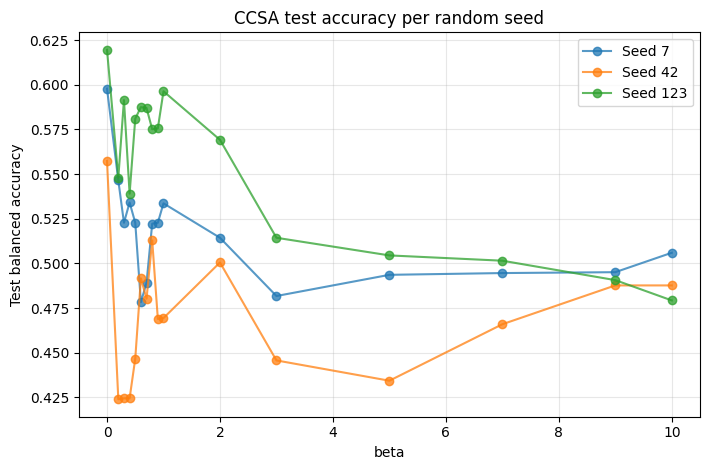

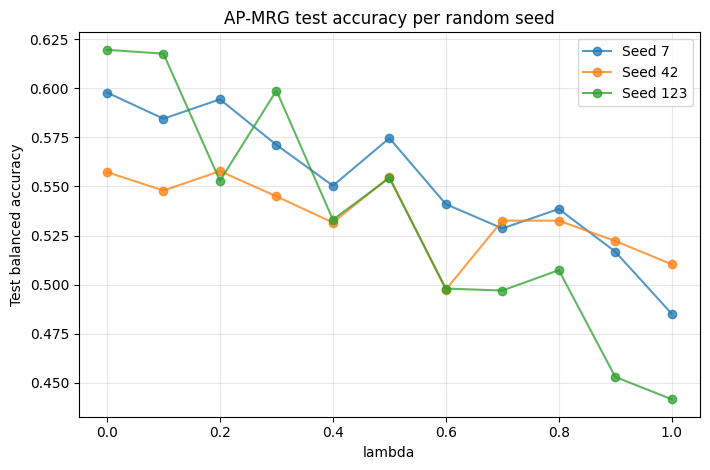

In [107]:
def plot_seedwise_scatter(df, x_col, title, filename):
    plt.figure(figsize=(7.2, 4.8))

    for seed in sorted(df["seed"].unique()):
        g = df[df["seed"] == seed]
        plt.plot(
            g[x_col],
            g["test_balanced_accuracy"],
            marker="o",
            linewidth=1.5,
            alpha=0.75,
            label=f"Seed {seed}"
        )

    plt.xlabel(x_col)
    plt.ylabel("Test balanced accuracy")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=220)
    plt.show()


plot_seedwise_scatter(
    ccsa_df,
    x_col="beta",
    title="CCSA test accuracy per random seed",
    filename="results/figures/ccsa_seedwise_test_accuracy.png"
)

plot_seedwise_scatter(
    apmrg_df[apmrg_df["lambda"] <= 1.0],
    x_col="lambda",
    title="AP-MRG test accuracy per random seed",
    filename="results/figures/apmrg_seedwise_test_accuracy.png"
)

Save final metrics and log

In [108]:
final_metrics = {
    "configuration": {
        "train_subjects_full": TRAIN_SUBJECTS_FULL,
        "train_subjects_small": TRAIN_SUBJECTS_SMALL,
        "test_subjects": TEST_SUBJECTS,
        "runs": RUNS,
        "task_interpretation": "EEGBCI runs 6, 10, 14: hands/fists vs feet motor imagery",
        "preprocessing": {
            "bandpass_hz": [LOW_FREQ, HIGH_FREQ],
            "sampling_rate_hz": RESAMPLE_RATE,
            "epoch_window_sec": [TMIN, TMAX],
            "normalization": "per-trial per-channel z-score"
        },
        "seeds": SEEDS,
        "training_protocol": "fixed epochs, no validation split, train on assigned training subjects",
        "epochs_baseline": EPOCHS_BASELINE,
        "epochs_sweep": EPOCHS_SWEEP,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "use_max_norm_eegnet": USE_MAX_NORM,
        "main_ccsa_beta_for_visualization": MAIN_CCSA_BETA,
        "main_apmrg_lambda_for_visualization": MAIN_APMRG_LAMBDA
    },
    "part1_raw": part1_df.to_dict(orient="records"),
    "part1_summary": part1_summary.to_dict(orient="records"),
    "part2_ccsa_raw": ccsa_df.to_dict(orient="records"),
    "part2_ccsa_summary": ccsa_summary.to_dict(orient="records"),
    "part3_mrg_band_table": mrg_band_table.to_dict(orient="records"),
    "part3_mrg_weights": mrg_weights.tolist(),
    "part3_apmrg_raw": apmrg_df.to_dict(orient="records"),
    "part3_apmrg_summary": apmrg_summary.to_dict(orient="records")
}

with open("results/metrics.json", "w") as f:
    json.dump(make_json_serializable(final_metrics), f, indent=2)


lines = []
lines.append("RESULTS SUMMARY")
lines.append("Protocol: fixed epochs, no validation split; train on assigned training subjects.")
lines.append("")
lines.append("PART 1")
lines.append(part1_compact.to_string(index=False))
lines.append("")
lines.append("PART 2 CCSA")
lines.append(part2_compact.to_string(index=False))
lines.append("")
lines.append("PART 3 AP-MRG")
lines.append(part3_compact.to_string(index=False))
lines.append("")
lines.append("AP-MRG band reliability table")
lines.append(mrg_band_table.to_string(index=False))

summary_text = "\n".join(lines)

with open("results/log.txt", "w") as f:
    f.write(summary_text)

print(summary_text)

print("\nSaved files:")
print("results/metrics.json")
print("results/log.txt")
print("results/*.csv")
print("results/figures/*.png")

RESULTS SUMMARY
Protocol: fixed epochs, no validation split; train on assigned training subjects.

PART 1
                  experiment_name  test_balanced_accuracy_mean  test_balanced_accuracy_std  test_balanced_accuracy_best  test_balanced_accuracy_worst  class_probe_accuracy_mean  subject_probe_accuracy_mean
   Part1_EEGNet_full_train_1_to_8                     0.591568                    0.025797                     0.619565                      0.557312                   0.873457                     0.598765
Part1_EEGNet_reduced_train_1_to_3                     0.556489                    0.023416                     0.589427                      0.537055                   0.804878                     0.780488

PART 2 CCSA
 beta  test_balanced_accuracy_mean  test_balanced_accuracy_std  test_balanced_accuracy_best  test_balanced_accuracy_worst  class_probe_accuracy_mean  subject_probe_accuracy_mean
  0.0                     0.591568                    0.025797                     0.